In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.dataset.split_data import split_data_Train_Val_Test, create_dataloaders_train_val_test
import scipy.integrate
from sklearn.preprocessing import StandardScaler
from src.utils.cox_models import *
scipy.integrate.simps = scipy.integrate.simpson

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
pp = Preprocessor()

In [3]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")
clean_mRNA_df = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)
Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818


In [4]:
df_mrna_clean = pp.eliminate_zero_genes(df_mRNA_raw_data, "Hugo_Symbol")
df_merged = TorchPreprocessing(clean_mRNA_df,df_clinical_data, 2000).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

Genes before Treshold: 818
count     818.000000
mean     2911.273839
std       351.415192
min         0.000000
25%      2709.250000
50%      2866.500000
75%      3078.500000
max      4575.000000
dtype: float64
Threshold (>80% zeros): 16352 samples
After the treshold: 818
Genes before Treshold: 2003
count    2003.000000
mean       76.306041
std       158.918820
min         0.000000
25%         0.000000
50%         0.000000
75%        20.000000
max       519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805


array(['Luminal A', 'TNBC', 'Luminal B', 'HER2-enriched'], dtype=object)

In [142]:
zero_reduced_df = pp.eliminate_zero_genes(comparation_df, "Tumor-Cancer")
print(f"Samples: {zero_reduced_df.shape[0]}, Genes: {zero_reduced_df.shape[1]}")
zero_reduced_df =  zero_reduced_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

Genes before Treshold: 1805
count    1805.000000
mean       30.929640
std        84.082264
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max       415.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1805
Samples: 519, Genes: 1806


In [143]:
results_df

,HER2-enriched,Luminal A,Luminal B,TNBC,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.879097,10.704586,10.782180,10.716942,10.726453,69262.336815,0.000000e+00,0.000000e+00
CCR7,6.044679,5.968886,6.192913,6.938782,6.166055,1634.501163,0.000000e+00,0.000000e+00
FBXO48,5.023124,4.763917,4.780206,4.962661,4.810496,6907.552264,0.000000e+00,0.000000e+00
PTPRN2,6.436115,7.635121,7.006290,5.565086,7.144821,1749.138908,0.000000e+00,0.000000e+00
TRIOBP,10.290598,10.180434,10.190821,10.256202,10.199346,42629.167766,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...
SSX4,0.762482,0.202256,0.332518,0.421870,0.283380,15.974664,4.389646e-13,4.399411e-13
RPTN,0.281796,0.270517,0.264407,0.518887,0.310740,15.355910,1.456288e-12,1.458717e-12
REXO1L1P,0.128429,0.201275,0.248773,0.140834,0.195561,15.321054,1.557997e-12,1.559728e-12
CSN1S1,0.152372,0.442308,0.377112,0.388976,0.410550,14.655928,5.644621e-12,5.647756e-12


In [144]:
N_GENES = 20
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES]
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma

In [145]:
Torch_preprocessing = TorchPreprocessing(df_mrna_clean, df_clinical_data, N_GENES)
Torch_preprocessing.genes_expression = top_genes_limma
X_scaled, durations, events, scaler = Torch_preprocessing.get_data_set()

Genes before Treshold: 23
count    23.000000
mean      2.217391
std       4.358446
min       0.000000
25%       0.000000
50%       0.000000
75%       1.500000
max      14.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 23


In [146]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)
len(surival_data_set)

519

In [147]:
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_data_Train_Val_Test(surival_data_set)

In [148]:
in_features = train_X.shape[1]
num_nodes = [32, 16]
out_features = 1
batch_norm = True
dropout = 0.3
output_bias = False

net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=num_nodes, out_features=out_features, batch_norm=batch_norm,
    dropout=dropout, output_bias=output_bias
)

In [149]:
model = CoxPH(net, tt.torchtuples.optim.Adam)

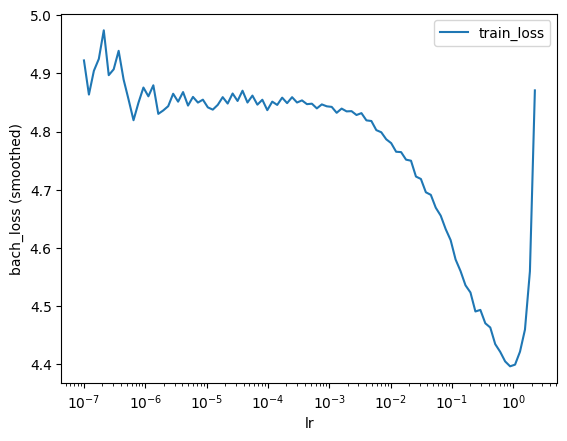

In [150]:
batch_size = 256
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=10)

_ = lrfinder.plot()

In [151]:
learning_rate = lrfinder.get_best_lr()
learning_rate

0.08902150854450441

In [152]:
model.optimizer.set_lr(0.01)


In [153]:
epochs = 200
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=10)]
verbose = True

In [154]:
%%time
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.8779,	val_loss: 3.5196
1:	[0s / 0s],		train_loss: 4.5478,	val_loss: 3.4860
2:	[0s / 0s],		train_loss: 4.5241,	val_loss: 3.4469
3:	[0s / 0s],		train_loss: 4.3752,	val_loss: 3.4056
4:	[0s / 0s],		train_loss: 4.2895,	val_loss: 3.3699
5:	[0s / 0s],		train_loss: 4.1696,	val_loss: 3.3494
6:	[0s / 0s],		train_loss: 4.2527,	val_loss: 3.3193
7:	[0s / 0s],		train_loss: 4.0097,	val_loss: 3.3097
8:	[0s / 0s],		train_loss: 4.0134,	val_loss: 3.3126
9:	[0s / 0s],		train_loss: 4.0143,	val_loss: 3.3403
10:	[0s / 0s],		train_loss: 3.9131,	val_loss: 3.3708
11:	[0s / 0s],		train_loss: 4.0036,	val_loss: 3.4253
12:	[0s / 0s],		train_loss: 3.6125,	val_loss: 3.4893
13:	[0s / 0s],		train_loss: 3.6564,	val_loss: 3.5324
14:	[0s / 0s],		train_loss: 3.5686,	val_loss: 3.5808
15:	[0s / 0s],		train_loss: 3.7213,	val_loss: 3.6391
16:	[0s / 0s],		train_loss: 3.6638,	val_loss: 3.6846
17:	[0s / 0s],		train_loss: 3.4484,	val_loss: 3.7210
CPU times: total: 1.42 s
Wall time: 513 ms


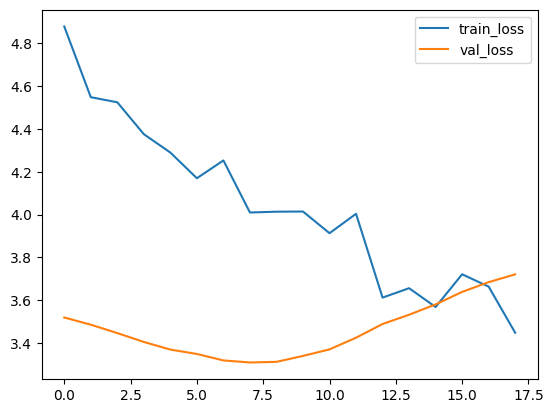

In [155]:
_ = log.plot()

In [156]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()

-3.3096952

In [157]:
_ = model.compute_baseline_hazards()

In [158]:
surv = model.predict_surv_df(input=test_X)
surv.shape

(275, 52)

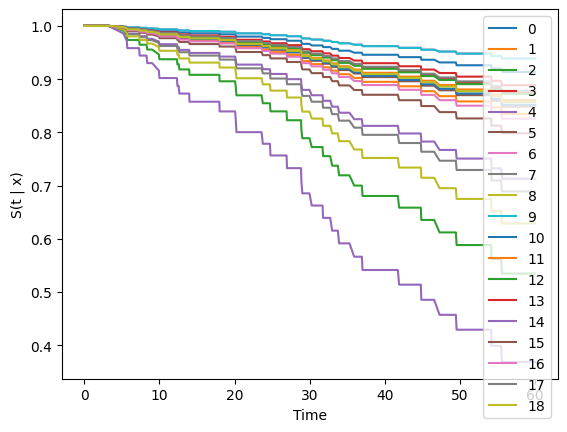

In [159]:
surv.iloc[:, :19].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel("Time")

In [160]:
test_durations = test_durations.cpu().detach().numpy()
test_events = test_events.cpu().detach().numpy()

In [161]:
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


In [162]:
print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.8472222222222222


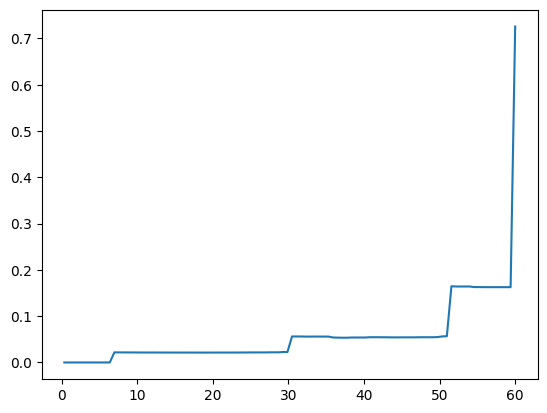

In [111]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [112]:
ev.integrated_brier_score(time_grid=time_grid)

0.05435824603927914

In [113]:
ev.integrated_nbll(time_grid)

0.19784914642082332